# **Proyecto ADMEAV**

> ODIR-5K es una base de datos médica utilizado para entrenar y evaluar sistemas de inteligencia artificial en la detección de enfermedades oculares.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/ADMEAV/Project'
TEST_DIR = '/content/drive/MyDrive/Colab Notebooks/ADMEAV/Project/Testing Images'
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/ADMEAV/Project/Training Images'

Mounted at /content/drive


## Lectura y Limpieza de Datos

> En esta parte del código se realizará la carga de datos y depuración debido al desbalance de la misma. Para ello, se transformará el Excel data.xlsx en un DataFrame limpio que solo contenga imágenes válidas y con etiquetas inequívocas.



In [ ]:
import pandas as pd
import os


df = pd.read_excel(f'{BASE_PATH}/data.xlsx')
def get_clean_label(diagnosis_text):
    text = str(diagnosis_text).lower(),oo

    if 'cataract' in text: return 'Cataract'
    if 'glaucoma' in text: return 'Glaucoma'
    if 'diabetes' in text or 'diabetic' in text: return 'Diabetes'
    if 'myopia' in text: return 'Myopia'
    if 'normal' in text: return 'Normal'

    return 'Other'

data_clean = [] # Diferenciamos ojo izquierdo y derecho

for _, row in df.iterrows():
    l_label = get_clean_label(row['Left-Diagnostic Keywords'])
    if l_label != 'Other':
        data_clean.append({
            'filename': row['Left-Fundus'],
            'label': l_label,
            'eye': 'Left'
        })

    r_label = get_clean_label(row['Right-Diagnostic Keywords'])
    if r_label != 'Other':
        data_clean.append({
            'filename': row['Right-Fundus'],
            'label': r_label,
            'eye': 'Right'
        })

df_v2 = pd.DataFrame(data_clean) # Creamos el DataFrame limpio

In [ ]:
print(f"\n--- RESUMEN DEL DATASET V2.0 ---")
print(f"Total de imágenes útiles encontradas: {len(df_v2)}")
print("\nDistribución de clases:")
print(df_v2['label'].value_counts())

import os
sample_file = df_v2.iloc[0]['filename']
full_path = os.path.join(TRAIN_DIR, sample_file)
print(f"\nVerificando ruta de prueba: {full_path}")
print(f"¿Existe el archivo?: {os.path.exists(full_path)}")


--- RESUMEN DEL DATASET V2.0 ---
Total de imágenes útiles encontradas: 4074

Distribución de clases:
label
Normal      3104
Glaucoma     324
Cataract     313
Myopia       253
Diabetes      80
Name: count, dtype: int64

Verificando ruta de prueba: /content/drive/MyDrive/Colab Notebooks/ADMEAV/Project/Training Images/0_left.jpg
¿Existe el archivo?: True


## Balanceo y Preprocesamiento

> Se realizará un balanceo de las clases a través de un "Undersampling" de la clase mayoritaria. Posteriormente se empleará una técnica denominada CLAHE, que servirá para mejorar el contraste local y aportar mayor nitidez a las imágenes.




In [ ]:
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

df_normal = df_v2[df_v2['label'] == 'Normal'].sample(n=500, random_state=42)
df_rest = df_v2[df_v2['label'] != 'Normal']
df_balanced = pd.concat([df_normal, df_rest]).sample(frac=1, random_state=42).reset_index(drop=True)

print("--- NUEVA DISTRIBUCIÓN EQUILIBRADA ---")
print(df_balanced['label'].value_counts())


train_df, test_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['label'], random_state=42)
print(f"\nImágenes para Entrenar: {len(train_df)}")
print(f"Imágenes para Testear: {len(test_df)}")


def preprocess_image(img):
    if img.dtype != 'uint8':
        img = img.astype('uint8')

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    final_img = final_img.astype('float32') / 255.0

    return final_img

--- NUEVA DISTRIBUCIÓN EQUILIBRADA ---
label
Normal      500
Glaucoma    324
Cataract    313
Myopia      253
Diabetes     80
Name: count, dtype: int64

Imágenes para Entrenar: 1176
Imágenes para Testear: 294


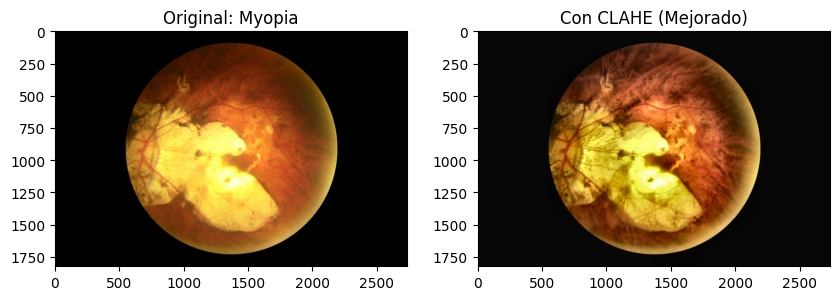

In [ ]:
import random

row = df_balanced.iloc[random.randint(1, 100)]
img_path = os.path.join(TRAIN_DIR, row['filename'])

if os.path.exists(img_path):
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    processed = preprocess_image(original)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(original); plt.title(f"Original: {row['label']}")
    plt.subplot(1, 2, 2); plt.imshow(processed); plt.title("Con CLAHE (Mejorado)")
    plt.show()
else:
    print("No se pudo cargar la imagen de prueba. Verifica la ruta IMG_DIR.")

## Modelo y Generadores

> Aquí se conectará los datos limpios y mejorados con una ResNet50, para ello se empleará un generador de entrenamiento (Con Data Augmentation para que aprenda más)



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

train_datagen = ImageDataGenerator(
    # rescale=1./255,
    preprocessing_function=preprocess_image,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(
    # rescale=1./255,
    preprocessing_function=preprocess_image
)

print("Generando flujos de datos...")

# Flujo de Entrenamiento
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# Flujo de Validación/Test
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=TRAIN_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Generando flujos de datos...
Found 1176 validated image filenames belonging to 5 classes.
Found 294 validated image filenames belonging to 5 classes.


In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nModelo V2.0 Compilado con éxito.")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Modelo V2.0 Compilado con éxito.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Entrenamiento

> Ahora se va a ejecutar el entrenamiento para ellos se va a usar Callbacks, que actúan como un sensor:


*   EarlyStopping: Si el modelo deja de mejorar, se para solo para no sobreentrenarse (overfitting).
*   ReduceLROnPlateau: Si el aprendizaje se estanca, el modelo "pisa el embrague" y reduce la velocidad de aprendizaje para intentar encontrar el camino óptimo.
* ModelCheckpoint: Guarda automáticamente la versión del modelo que mejor precisión haya tenido.



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import cv2
import numpy as np


def preprocess_image(img):
    img_uint8 = img.astype('uint8')


    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_img.astype('float32')


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=TRAIN_DIR,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False


inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


checkpointer = ModelCheckpoint(filepath='mejor_modelo_v2.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

print("\n--- Iniciando el Gran Entrenamiento V2.0 ---")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    callbacks=[checkpointer, stop, reduce_lr]
)

Found 1176 validated image filenames belonging to 5 classes.
Found 294 validated image filenames belonging to 5 classes.

--- Iniciando el Gran Entrenamiento V2.0 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.3416 - loss: 2.0975 
Epoch 1: val_accuracy improved from -inf to 0.63265, saving model to mejor_modelo_v2.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 648s 17s/step - accuracy: 0.3444 - loss: 2.0884 - val_accuracy: 0.6327 - val_loss: 1.0116 - learning_rate: 1.0000e-04
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6281 - loss: 1.2092
Epoch 2: val_accuracy improved from 0.63265 to 0.70068, saving model to mejor_modelo_v2.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 287s 8s/step - accuracy: 0.6287 - loss: 1.2070 - val_accuracy: 0.7007 - val_loss: 0.8465 - learning_rate: 1.0000e-04
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6741 - loss: 1.0083
Epoch 3: val_accuracy improved from 0.70068 to 0.72449, saving model to mejor_modelo_v2.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 285s 8s/step - accuracy: 0.6741 - loss: 1.0081 - val_accuracy: 0.7245 - val_loss: 0.7820 - learning_rate: 1.0000e-04
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6983 - loss: 0.8974
Epoch 4: val_accuracy improved from 0.72449 to 0.72789, saving model to mejor_modelo_v2.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 320s 8s/step - accuracy: 0.6983 - loss: 0.8975 - val_accuracy: 0.7279 - val_loss: 0.7211 - learning_rate: 1.0000e-04
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6896 - loss: 0.8119
Epoch 5: val_accuracy improved from 0.72789 to 0.73810, saving model to mejor_modelo_v2.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 285s 8s/step - accuracy: 0.6900 - loss: 0.8125 - val_accuracy: 0.7381 - val_loss: 0.6953 - learning_rate: 1.0000e-04


## Evaluación del Modelo

> Primero se empleará la matriz de confusión para evaluar el rendimiento del modelo, permitiendo conocer el numero de predicciones correctas e incorrectas. Además se ha realizado un informe de clasificación que proporciona métricas clave para cada clase individualmente y también un promedio general.



10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step


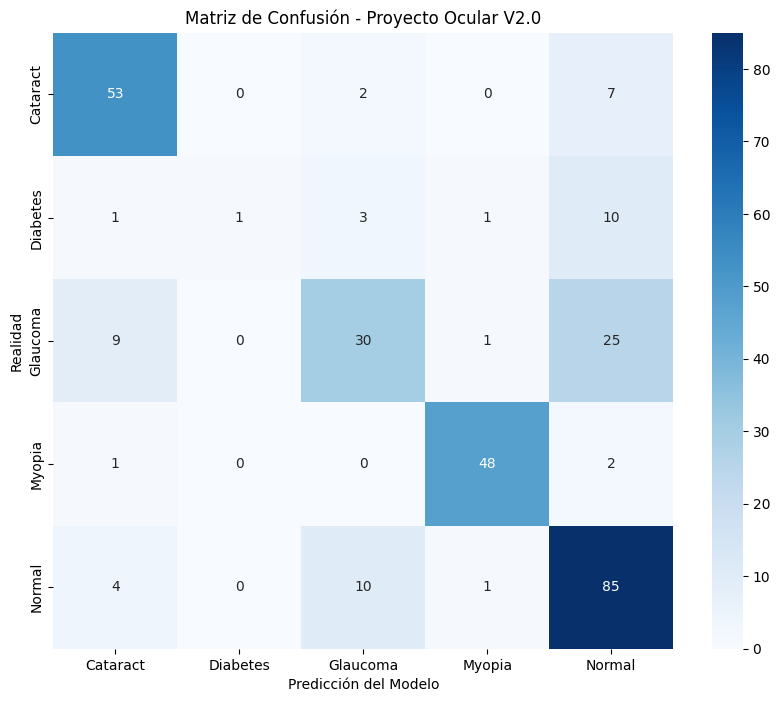


Informe de Clasificación:
              precision    recall  f1-score   support

    Cataract       0.78      0.85      0.82        62
    Diabetes       1.00      0.06      0.12        16
    Glaucoma       0.67      0.46      0.55        65
      Myopia       0.94      0.94      0.94        51
      Normal       0.66      0.85      0.74       100

    accuracy                           0.74       294
   macro avg       0.81      0.63      0.63       294
weighted avg       0.75      0.74      0.71       294



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión - Proyecto Ocular V2.0')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

print("\nInforme de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))

### Plot Training and Validation History


> Se emplea el histórico generado durante el entrenamiento del modelo para graficar la precisión y la pérdida a lo largo de las épocas, tanto para el conjunto de entrenamiento como para el de validación. Esto nos permitirá visualizar el progreso del aprendizaje y detectar posibles problemas como el sobreajuste o el subajuste.





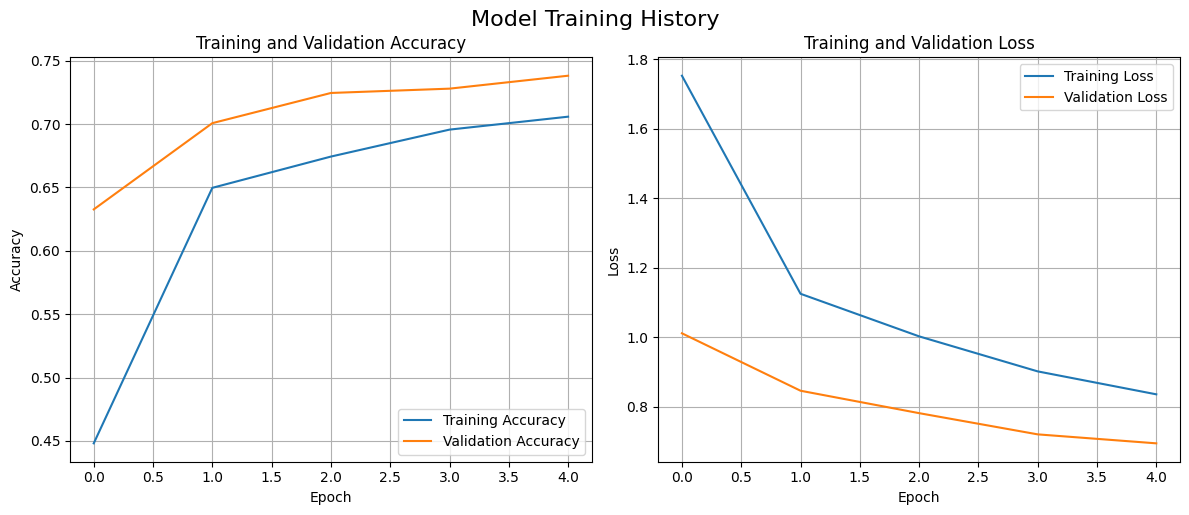

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.suptitle('Model Training History', y=1.02, fontsize=16)
plt.show()

### Plot Multi-class ROC Curves and AUC

> Se calcula y grafica las curvas ROC para cada una de las clases, utilizando un enfoque 'uno contra el resto', además se calculará el Área Bajo la Curva (AUC) para cada clase y el micro-promedio AUC. Esto proporcionará una medida robusta de la capacidad de discriminación del modelo entre las diferentes categorías, complementando la matriz de confusión y el informe de clasificación.




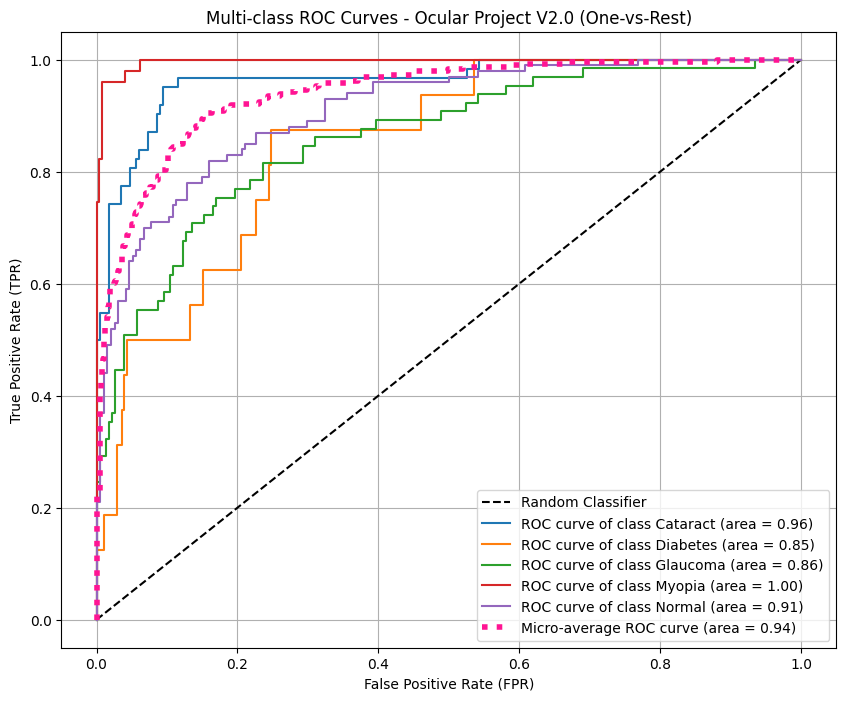

Micro-average ROC AUC: 0.94
ROC AUC for class Cataract: 0.96
ROC AUC for class Diabetes: 0.85
ROC AUC for class Glaucoma: 0.86
ROC AUC for class Myopia: 1.00
ROC AUC for class Normal: 0.91


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import numpy as np

# Convert y_true (class indices) to one-hot encoded format
y_true_reshaped = np.array(y_true).reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
y_true_one_hot = encoder.fit_transform(y_true_reshaped)

# Get the number of classes
n_classes = len(class_labels)

# Initialize dictionaries for FPR, TPR, and ROC AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class (one-vs-rest)
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calculate micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(y_true_one_hot.ravel(), Y_pred.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Random Classifier line

# Plot individual class ROC curves
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:0.2f})')

# Plot micro-average ROC curve
plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average ROC curve (area = {roc_auc_micro:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multi-class ROC Curves - Ocular Project V2.0 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Micro-average ROC AUC: {roc_auc_micro:0.2f}")
for i in range(n_classes):
    print(f"ROC AUC for class {class_labels[i]}: {roc_auc[i]:0.2f}")

## Resumen:

### Hallazgos Clave del Análisis de Datos
* El historial de entrenamiento del modelo, incluyendo la precisión de entrenamiento y validación, y la pérdida a lo largo de los periodos, se visualizó correctamente, proporcionando una visión general clara del proceso de aprendizaje.
* El modelo demostró una sólida capacidad discriminativa general, alcanzando un micropromedio de AUC ROC de 0,94.
* Las puntuaciones de AUC ROC específicas de cada clase mostraron un rendimiento variable:
* El modelo logró una discriminación perfecta para la clase "Miopía", con un AUC ROC de 1,00.
* El rendimiento también fue excelente para "Catarata", con un AUC ROC de 0,96.
* La clase "Normal" tuvo un buen AUC ROC de 0,91.
* Las clases "Glaucoma" y "Diabetes" mostraron AUC ROC ligeramente inferiores, pero aún aceptables, de 0,86 y 0,85, respectivamente.

### Perspectivas o próximos pasos
* El alto AUC ROC para "Miopía" y "Cataratas" sugiere que el modelo es muy eficaz para identificar estas afecciones. Este excelente rendimiento podría aprovecharse para programas de detección temprana o de cribado dirigidos a estas afecciones específicas.
* Si bien el rendimiento general es sólido, las puntuaciones relativamente bajas del AUC ROC para "Diabetes" y "Glaucoma" indican áreas de mejora potencial. El trabajo futuro podría centrarse en técnicas para mejorar la capacidad del modelo para distinguir estas clases, como la recopilación de datos más diversos para estas afecciones específicas, la aplicación de ingeniería de características más avanzada o la exploración de ajustes del modelo específicos para cada clase.